# Name of the Contributer : Gauri Sandesh Dasav
# DATASET : 311_Customer_Service_Requests_Analysis
# PACKAGES/MODULES USED : NUMPY, PANDAS, MATPLOTLIB, SEABORN, DATETIME, SCIPY

# --------------------------------------------------------------------------------------------------------------

# 1.Understand the Dataset , Importing the Dataset and doing Data Preprocessing on the dataset . 

In [1]:
# importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
%matplotlib inline
import seaborn as sns
import datetime

from scipy.stats import chi2_contingency
from scipy.stats import chi2

In [2]:
# reading the dataset
# Note: Our Dataset is very large so setting low_memory to false
dataset = pd.read_csv('311_Service_Requests_from_2010_to_Present.csv', low_memory = False)

In [3]:
# View the top 5 elements of the dataset
dataset.head(5)

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location
0,32310363,12/31/2015 11:59:45 PM,01/01/2016 12:55:15 AM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10034.0,71 VERMILYEA AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.865682,-73.923501,"(40.86568153633767, -73.92350095571744)"
1,32309934,12/31/2015 11:59:44 PM,01/01/2016 01:26:57 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11105.0,27-07 23 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.775945,-73.915094,"(40.775945312321085, -73.91509393898605)"
2,32309159,12/31/2015 11:59:29 PM,01/01/2016 04:51:03 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10458.0,2897 VALENTINE AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.870325,-73.888525,"(40.870324522111424, -73.88852464418646)"
3,32305098,12/31/2015 11:57:46 PM,01/01/2016 07:43:13 AM,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,10461.0,2940 BAISLEY AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.835994,-73.828379,"(40.83599404683083, -73.82837939584206)"
4,32306529,12/31/2015 11:56:58 PM,01/01/2016 03:24:42 AM,NYPD,New York City Police Department,Illegal Parking,Blocked Sidewalk,Street/Sidewalk,11373.0,87-14 57 ROAD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.733060,-73.874170,"(40.733059618956815, -73.87416975810375)"


In [4]:
# shape of the dataset
dataset.shape

(364558, 53)

In [5]:
dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364558 entries, 0 to 364557
Data columns (total 53 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Unique Key                      364558 non-null  int64  
 1   Created Date                    364558 non-null  object 
 2   Closed Date                     362177 non-null  object 
 3   Agency                          364558 non-null  object 
 4   Agency Name                     364558 non-null  object 
 5   Complaint Type                  364558 non-null  object 
 6   Descriptor                      358057 non-null  object 
 7   Location Type                   364425 non-null  object 
 8   Incident Zip                    361560 non-null  float64
 9   Incident Address                312859 non-null  object 
 10  Street Name                     312859 non-null  object 
 11  Cross Street 1                  307370 non-null  object 
 12  Cross Street 2  

#### There are a lot of columns in our dataset but I don't need all of them. So I will drop the columns that have a very large number of null values in it. Also I don't need the unnecessary columns, so I will drop them.

In [6]:
# viewing the columns
dataset.columns

Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name',
       'Complaint Type', 'Descriptor', 'Location Type', 'Incident Zip',
       'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2',
       'Intersection Street 1', 'Intersection Street 2', 'Address Type',
       'City', 'Landmark', 'Facility Type', 'Status', 'Due Date',
       'Resolution Description', 'Resolution Action Updated Date',
       'Community Board', 'Borough', 'X Coordinate (State Plane)',
       'Y Coordinate (State Plane)', 'Park Facility Name', 'Park Borough',
       'School Name', 'School Number', 'School Region', 'School Code',
       'School Phone Number', 'School Address', 'School City', 'School State',
       'School Zip', 'School Not Found', 'School or Citywide Complaint',
       'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location',
       'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp',
       'Bridge Highway Segment', 'Garage Lot Name', 'Ferry 

- Columns with most of its values as null are dropped
- Agency and Agency Name are more or less same, so I am dropping Agency Name
- Dropping other unnecessary columns like Location, Incident Adrress, Street Name, X Coordinate (State Plane), Y Coordinate (State Plane)  as we are already considering LATITUDE and LONGITUDE
- Dropping other unnecessary columns

In [7]:
# dropping the irrelevant columns
drop_columns = ['Agency Name','Incident Address','Street Name','Cross Street 1','Cross Street 2','Intersection Street 1',
'Intersection Street 2','Address Type','Park Facility Name','Park Borough','School Name',
'School Number','School Region','School Code','School Phone Number','School Address','School City',
'School State','School Zip','School Not Found','School or Citywide Complaint','Vehicle Type',
'Taxi Company Borough','Taxi Pick Up Location','Bridge Highway Name','Bridge Highway Direction',
'Road Ramp','Bridge Highway Segment','Garage Lot Name','Ferry Direction','Ferry Terminal Name','Landmark',
'X Coordinate (State Plane)','Y Coordinate (State Plane)','Due Date','Resolution Action Updated Date','Community Board','Facility Type',
'Location']

dataset = dataset.drop(drop_columns, axis=1)

In [8]:
# checking the shape of our dataset
dataset.shape

(364558, 14)

#### So we are upto 14 columns from 53...That's a lot of reduction !

- ### Now check for null values, data type of the columns etc.

In [9]:
# checking the info of the dataset
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364558 entries, 0 to 364557
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Unique Key              364558 non-null  int64  
 1   Created Date            364558 non-null  object 
 2   Closed Date             362177 non-null  object 
 3   Agency                  364558 non-null  object 
 4   Complaint Type          364558 non-null  object 
 5   Descriptor              358057 non-null  object 
 6   Location Type           364425 non-null  object 
 7   Incident Zip            361560 non-null  float64
 8   City                    361561 non-null  object 
 9   Status                  364558 non-null  object 
 10  Resolution Description  364558 non-null  object 
 11  Borough                 364558 non-null  object 
 12  Latitude                360528 non-null  float64
 13  Longitude               360528 non-null  float64
dtypes: float64(3), int64

In [10]:
# checking the number of null values in the columns
dataset.isnull().sum()

Unique Key                   0
Created Date                 0
Closed Date               2381
Agency                       0
Complaint Type               0
Descriptor                6501
Location Type              133
Incident Zip              2998
City                      2997
Status                       0
Resolution Description       0
Borough                      0
Latitude                  4030
Longitude                 4030
dtype: int64

In [11]:
dataset.isnull().sum()

Unique Key                   0
Created Date                 0
Closed Date               2381
Agency                       0
Complaint Type               0
Descriptor                6501
Location Type              133
Incident Zip              2998
City                      2997
Status                       0
Resolution Description       0
Borough                      0
Latitude                  4030
Longitude                 4030
dtype: int64

In [12]:
# since all the cases are of closed cases we can now drop the column Status as every value of its data are same
dataset = dataset.drop(['Status'], axis = 1)

In [13]:
dataset.shape

(364558, 13)

In [14]:
# out of the remaining columns only Descriptor, Latitude and Longitude has over 1k null values
dataset = dataset[(dataset['Descriptor'].notnull()) & (dataset['Latitude'].notnull()) &(dataset['Longitude'].notnull())]

dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 354103 entries, 0 to 364557
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Unique Key              354103 non-null  int64  
 1   Created Date            354103 non-null  object 
 2   Closed Date             354045 non-null  object 
 3   Agency                  354103 non-null  object 
 4   Complaint Type          354103 non-null  object 
 5   Descriptor              354103 non-null  object 
 6   Location Type           353991 non-null  object 
 7   Incident Zip            354063 non-null  float64
 8   City                    354063 non-null  object 
 9   Resolution Description  354103 non-null  object 
 10  Borough                 354103 non-null  object 
 11  Latitude                354103 non-null  float64
 12  Longitude               354103 non-null  float64
dtypes: float64(3), int64(1), object(9)
memory usage: 37.8+ MB


In [15]:
# rechecking remaining null values
dataset.isnull().sum()

Unique Key                  0
Created Date                0
Closed Date                58
Agency                      0
Complaint Type              0
Descriptor                  0
Location Type             112
Incident Zip               40
City                       40
Resolution Description      0
Borough                     0
Latitude                    0
Longitude                   0
dtype: int64

In [16]:
# still there are few null values in our dataset. we will remove them
dataset = dataset[(dataset['Location Type'].notnull()) & (dataset['Incident Zip'].notnull()) &(dataset['City'].notnull())]

# rechecking for null values
dataset.isnull().sum()

Unique Key                 0
Created Date               0
Closed Date               58
Agency                     0
Complaint Type             0
Descriptor                 0
Location Type              0
Incident Zip               0
City                       0
Resolution Description     0
Borough                    0
Latitude                   0
Longitude                  0
dtype: int64

-- So all Null values are removed from our dataset

In [17]:
# checking the shape our datset
dataset.shape

(353949, 13)

**2.basic data exploratory analysis:**

2.1 Draw a frequency plot for null values

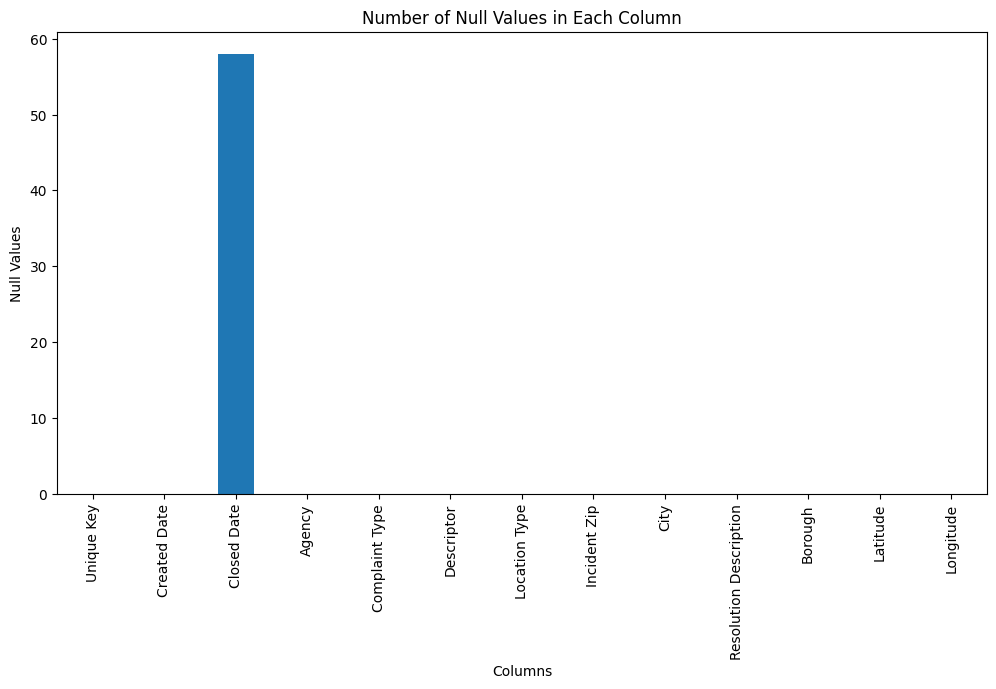

In [18]:
null_counts = dataset.isnull().sum()

plt.figure(figsize=(12,6))
null_counts.plot(kind='bar')
plt.title("Number of Null Values in Each Column")
plt.xlabel("Columns")
plt.ylabel("Null Values")
plt.show()

2.2Missing value treatment

In [19]:
dataset.isnull().sum()

Unique Key                 0
Created Date               0
Closed Date               58
Agency                     0
Complaint Type             0
Descriptor                 0
Location Type              0
Incident Zip               0
City                       0
Resolution Description     0
Borough                    0
Latitude                   0
Longitude                  0
dtype: int64

2.2.1 Remove records where Closed Date is null

In [20]:
dataset = dataset[dataset['Closed Date'].notnull()]

Verify Removal

In [21]:
dataset['Closed Date'].isnull().sum()

0

2.3Analyze the date column, and remove entries that have an incorrect timeline

In [22]:
dataset['Created Date'] = pd.to_datetime(dataset['Created Date'])
dataset['Closed Date'] = pd.to_datetime(dataset['Closed Date'])

C:\Users\Admin\AppData\Local\Temp\ipykernel_6424\475688951.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset['Created Date'] = pd.to_datetime(dataset['Created Date'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_6424\475688951.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dataset['Closed Date'] = pd.to_datetime(dataset['Closed Date'])


Remove Incorrect Timeline Entries

Some records may have Closed Date earlier than Created Date. Remove them.

In [23]:
dataset = dataset[dataset['Closed Date'] >= dataset['Created Date']]

2.3.1 Calculate Time Elapsed

Create a new column for request closing time.

In [24]:
dataset['Request_Closing_Time'] = dataset['Closed Date'] - dataset['Created Date']

2.3.2 Convert Time to Seconds

In [25]:
dataset['Request_Closing_Time'] = dataset['Request_Closing_Time'].dt.total_seconds()

2.3.3 View Descriptive Statistics


In [26]:
dataset['Request_Closing_Time'].describe()

count    3.538910e+05
mean     1.508406e+04
std      2.100190e+04
min      6.100000e+01
25%      4.531000e+03
50%      9.605000e+03
75%      1.883500e+04
max      2.134342e+06
Name: Request_Closing_Time, dtype: float64

This shows:

mean
minimum
maximum
standard deviation


2.3.4 Check Null Values in Complaint Type and City

In [27]:
dataset[['Complaint Type','City']].isnull().sum()

Complaint Type    0
City              0
dtype: int64

2.3.5 Replace Missing City Values

In [28]:
dataset['City'].fillna('Unknown City', inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_6424\897124927.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['City'].fillna('Unknown City', inplace=True)


2.3.6 Frequency Plot for Complaints in Each City

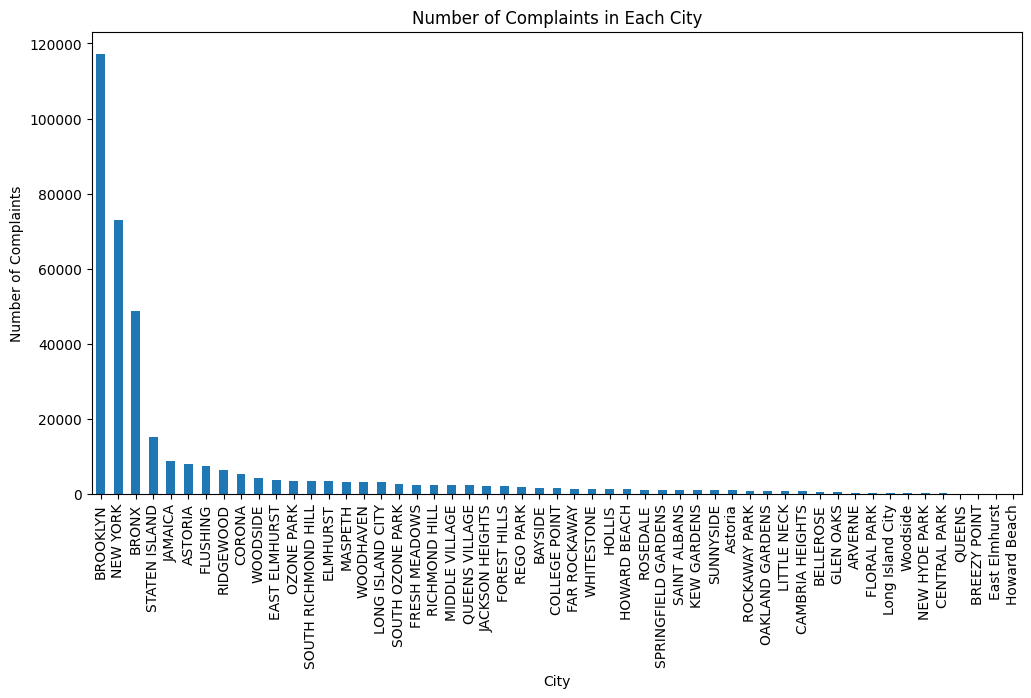

In [29]:
plt.figure(figsize=(12,6))
dataset['City'].value_counts().plot(kind='bar')
plt.title("Number of Complaints in Each City")
plt.xlabel("City")
plt.ylabel("Number of Complaints")
plt.show()

2.3.7 Scatter Plot for Brooklyn Complaints

In [30]:
brooklyn = dataset[dataset['City'] == 'BROOKLYN']

Then scatter plot:

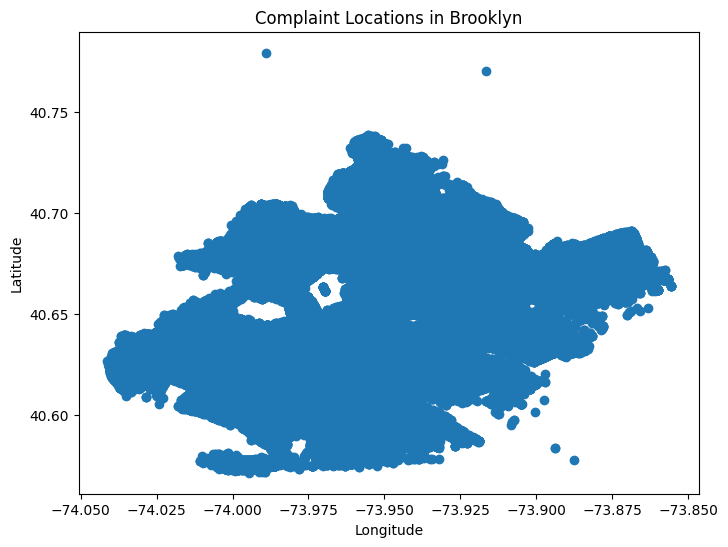

In [31]:
plt.figure(figsize=(8,6))
plt.scatter(brooklyn['Longitude'], brooklyn['Latitude'])
plt.title("Complaint Locations in Brooklyn")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

Hexbin Plot for Complaint Density

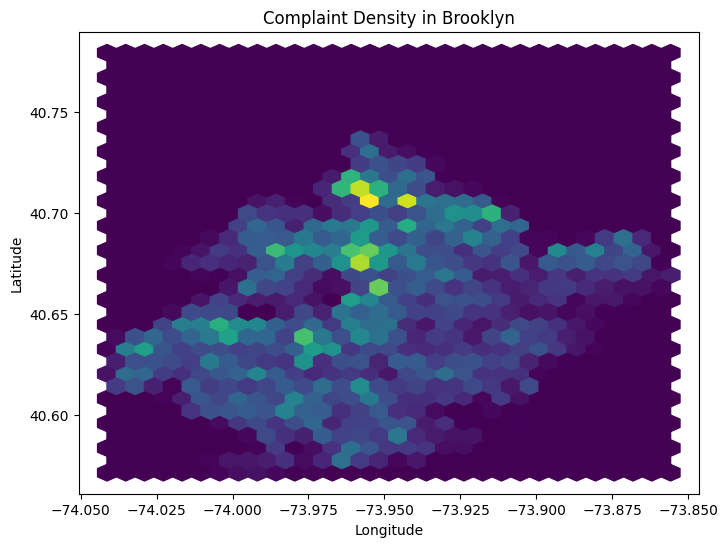

In [32]:
plt.figure(figsize=(8,6))
plt.hexbin(brooklyn['Longitude'], brooklyn['Latitude'], gridsize=30)
plt.title("Complaint Density in Brooklyn")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

**3.1 Plot a Bar Graph for Types of Complaints**

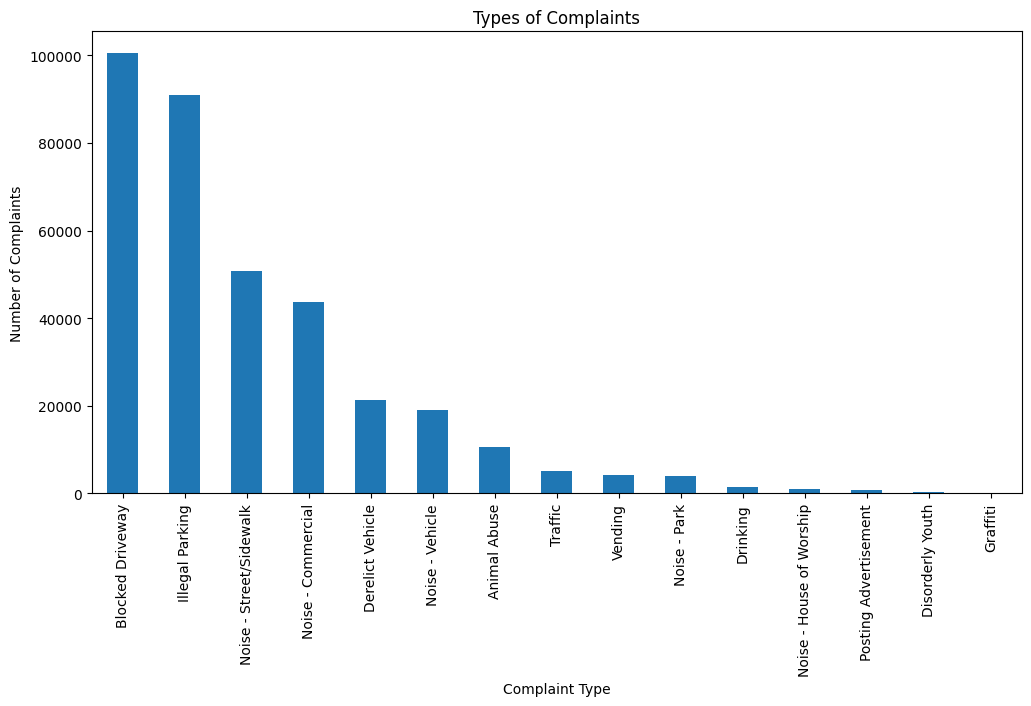

In [33]:
complaint_counts = dataset['Complaint Type'].value_counts()

plt.figure(figsize=(12,6))
complaint_counts.plot(kind='bar')
plt.title("Types of Complaints")
plt.xlabel("Complaint Type")
plt.ylabel("Number of Complaints")
plt.show()

3.2 Check Frequency of Complaint Types for New York City

In [34]:
nyc = dataset[dataset['City'] == 'NEW YORK']

nyc['Complaint Type'].value_counts()

Complaint Type
Noise - Street/Sidewalk     22079
Noise - Commercial          18666
Illegal Parking             14366
Noise - Vehicle              6178
Blocked Driveway             2686
Vending                      2619
Animal Abuse                 1926
Traffic                      1748
Noise - Park                 1200
Derelict Vehicle              688
Drinking                      320
Noise - House of Worship      217
Disorderly Youth               80
Posting Advertisement          49
Graffiti                       25
Name: count, dtype: int64

3.3 Find Top 10 Complaint Types

In [35]:
dataset['Complaint Type'].value_counts().head(10)

Complaint Type
Blocked Driveway           100455
Illegal Parking             91057
Noise - Street/Sidewalk     50791
Noise - Commercial          43623
Derelict Vehicle            21419
Noise - Vehicle             19122
Animal Abuse                10500
Traffic                      5161
Vending                      4162
Noise - Park                 3994
Name: count, dtype: int64

3.4 Display Complaint Types in Each City

In [36]:
dataset.groupby(['City','Complaint Type']).size()

City      Complaint Type         
ARVERNE   Animal Abuse                46
          Blocked Driveway            50
          Derelict Vehicle            32
          Disorderly Youth             2
          Drinking                     1
                                    ... 
Woodside  Blocked Driveway            27
          Derelict Vehicle             8
          Illegal Parking            124
          Noise - Commercial           2
          Noise - Street/Sidewalk      5
Length: 629, dtype: int64

3.5 Create DataFrame with Cities as Columns

In [37]:
df_new = pd.crosstab(dataset['Complaint Type'], dataset['City'])

df_new.head()

City,ARVERNE,ASTORIA,Astoria,BAYSIDE,BELLEROSE,BREEZY POINT,BRONX,BROOKLYN,CAMBRIA HEIGHTS,CENTRAL PARK,...,SAINT ALBANS,SOUTH OZONE PARK,SOUTH RICHMOND HILL,SPRINGFIELD GARDENS,STATEN ISLAND,SUNNYSIDE,WHITESTONE,WOODHAVEN,WOODSIDE,Woodside
Complaint Type,,,,,,,,,,,,,,,,,,,,,
Animal Abuse,46,170,0,53,15,2,1966,3185,15,0,...,43,74,40,42,786,40,43,57,111,0
Blocked Driveway,50,3436,159,513,138,3,17048,36414,177,0,...,318,1202,1945,330,2844,278,279,1363,2036,27
Derelict Vehicle,32,426,14,231,120,3,2398,6242,148,0,...,248,425,356,266,2180,17,279,369,298,8
Disorderly Youth,2,5,0,2,2,0,66,79,0,0,...,1,2,2,0,25,2,1,0,1,0
Drinking,1,43,0,1,1,1,205,291,0,0,...,3,14,25,6,188,12,3,4,15,0


**4.1 Chart Showing Complaint Types in Each City**

This chart will show different complaint types with different colors.

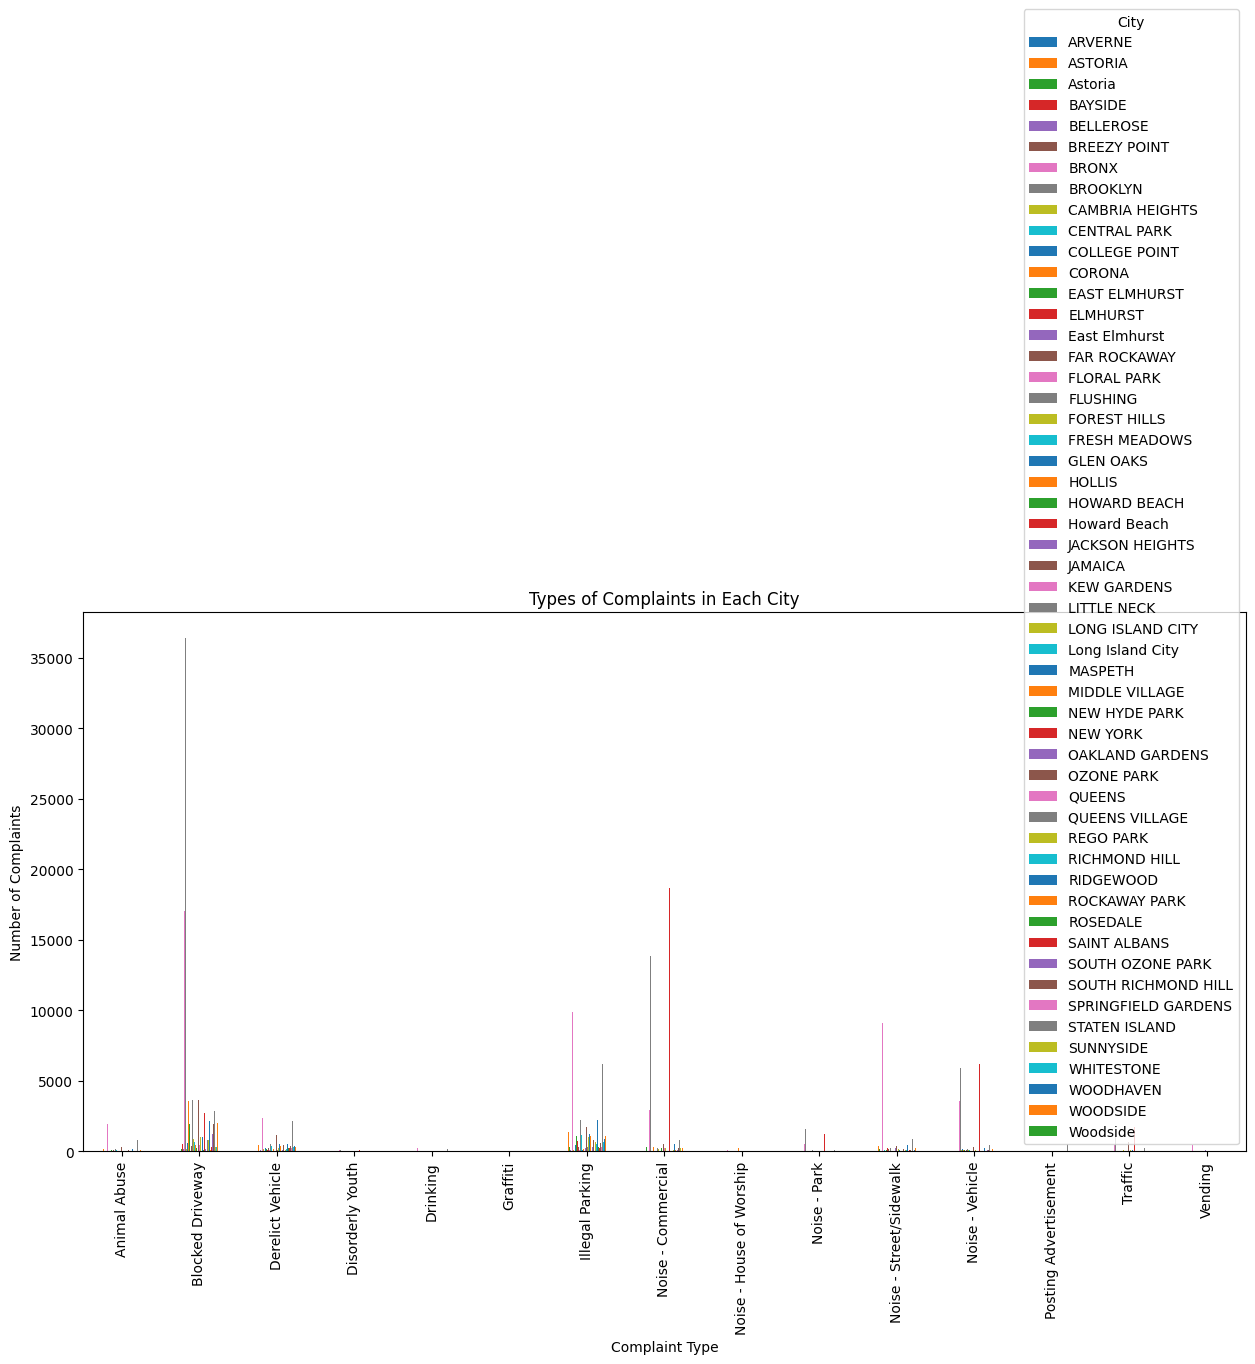

In [38]:
df_new.plot(kind='bar', figsize=(15,7))

plt.title("Types of Complaints in Each City")
plt.xlabel("Complaint Type")
plt.ylabel("Number of Complaints")

plt.show()

This graph compares complaint types across cities.

**4.2 Sort Complaint Types Based on Average Request Closing Time**


        Group by complaint type and calculate average response time.

In [39]:
avg_time = dataset.groupby('Complaint Type')['Request_Closing_Time'].mean()

Sort the values:

In [40]:
avg_time_sorted = avg_time.sort_values()

avg_time_sorted.head(10)

Complaint Type
Posting Advertisement        7287.171091
Noise - Commercial          11042.455562
Noise - House of Worship    11410.395656
Noise - Park                12196.250125
Noise - Street/Sidewalk     12219.275836
Traffic                     12324.517729
Disorderly Youth            12395.754777
Noise - Vehicle             12586.495921
Drinking                    13805.907791
Vending                     14355.265738
Name: Request_Closing_Time, dtype: float64

This shows complaint types with fastest response times.

```
Visualization of Average Response Time
```

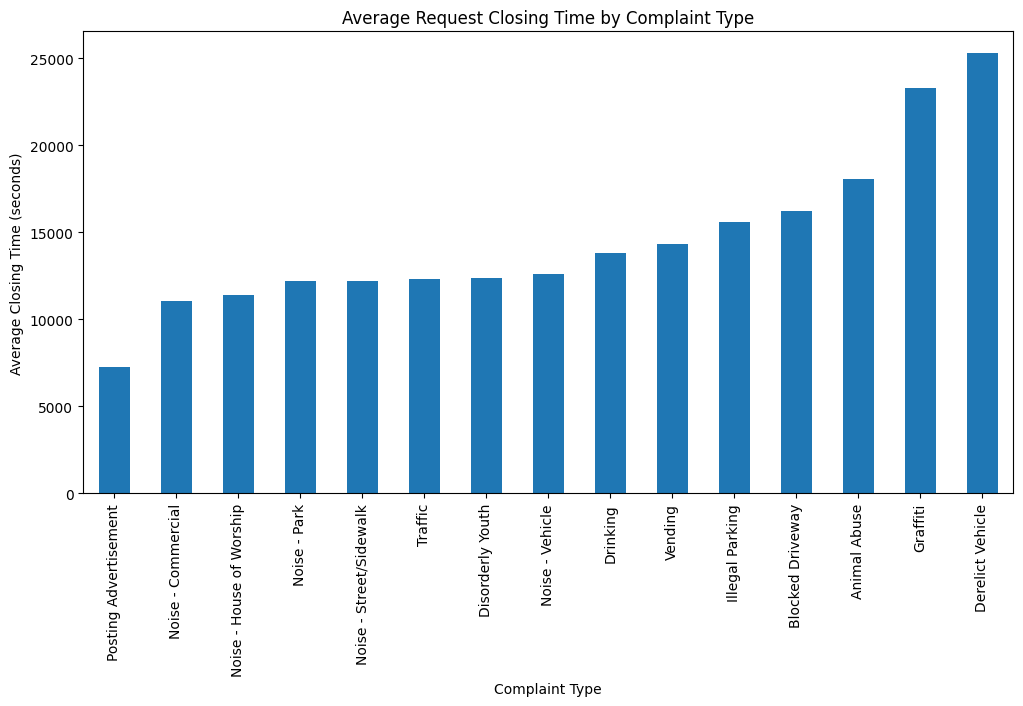

In [41]:
avg_time_sorted.plot(kind='bar', figsize=(12,6))

plt.title("Average Request Closing Time by Complaint Type")
plt.xlabel("Complaint Type")
plt.ylabel("Average Closing Time (seconds)")

plt.show()


# Task 5

Check whether the average response time across complaint types is similar

First calculate the average Request Closing Time.

In [42]:
dataset.groupby('Complaint Type')['Request_Closing_Time'].mean()

Complaint Type
Animal Abuse                18052.146476
Blocked Driveway            16217.841222
Derelict Vehicle            25281.668519
Disorderly Youth            12395.754777
Drinking                    13805.907791
Graffiti                    23276.343949
Illegal Parking             15582.870960
Noise - Commercial          11042.455562
Noise - House of Worship    11410.395656
Noise - Park                12196.250125
Noise - Street/Sidewalk     12219.275836
Noise - Vehicle             12586.495921
Posting Advertisement        7287.171091
Traffic                     12324.517729
Vending                     14355.265738
Name: Request_Closing_Time, dtype: float64

5.1 Visualize the Average Response Time

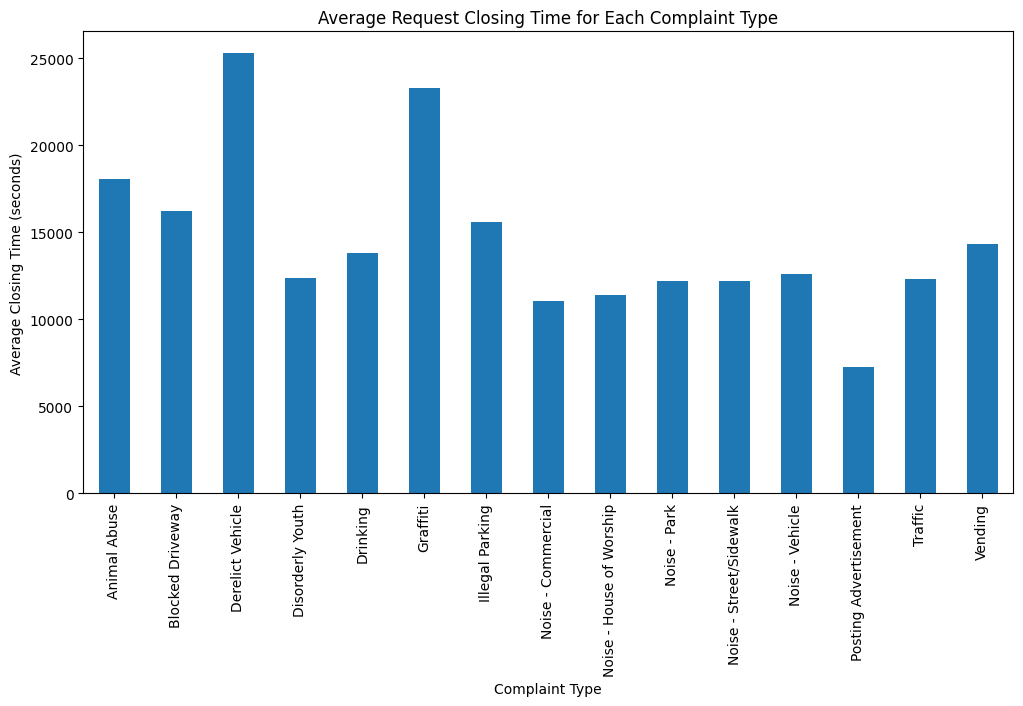

In [43]:
avg_response = dataset.groupby('Complaint Type')['Request_Closing_Time'].mean()

plt.figure(figsize=(12,6))
avg_response.plot(kind='bar')

plt.title("Average Request Closing Time for Each Complaint Type")
plt.xlabel("Complaint Type")
plt.ylabel("Average Closing Time (seconds)")

plt.show()

This graph shows which complaints take longer to resolve.


# Task 6
**Identify significant variables using p-values**

For this project we check whether Complaint Type affects Request Closing Time.

In [44]:
from scipy.stats import kruskal

# Task 7
**Perform Kruskal-Wallis H Test**

Create groups of response time for each complaint type.

In [45]:
groups = [group["Request_Closing_Time"].values 
          for name, group in dataset.groupby("Complaint Type")]

Now perform the test:

In [46]:
kruskal_test = kruskal(*groups)

print(kruskal_test)

KruskalResult(statistic=11839.696112265134, pvalue=0.0)


**Interpretation**

**Check the p-value:**

p-value < 0.05 → Reject H₀
→ Response time differs between complaint types.
p-value > 0.05 → Fail to Reject H₀
→ Response time is similar across complaint types.

# Task 8: Observations

You can write something like this:

Observations

      1.The dataset contains service request complaints from different cities in New York.

      2. After performing data cleaning, records with missing Closed Date were removed to ensure accurate calculation of response time.

      3. The majority of complaints are concentrated in cities such as Brooklyn, New York, and Queens.
        Some complaint types occur more frequently than others. Noise-related complaints are among the most common.

      4.The visualization of complaints across cities shows that different cities experience different patterns of complaint types.

       5. The Request Closing Time was calculated by finding the difference between the Created Date and Closed Date, and converting the result into seconds.
        From the analysis of average response time, some complaint types take longer to resolve compared to others.

       6. The Kruskal-Wallis statistical test was used to check whether the response time differs significantly across complaint types.

       7. Based on the p-value obtained from the Kruskal-Wallis test:
        If the p-value is less than 0.05, we reject the null hypothesis and conclude that response times are significantly different for different complaint types.

       8. If the p-value is greater than 0.05, we fail to reject the null hypothesis and conclude that response times are similar across complaint types.